
========== Задача 1.1 ==========
  Точка 1: x=(0.666667, 2.666667), f=3.666667, тип=min, λ=(0.0000, 0.0000, 0.0000), дост.усл.II: подтверждён
  Точка 2: x=(2.000000, 0.000000), f=9.000000, тип=max, λ=(0.0000, 0.0000, -4.0000), дост.усл.II: не выполнен
  Точка 3: x=(0.000000, 3.000000), f=4.000000, тип=max, λ=(0.0000, -1.0000, 0.0000), дост.усл.II: не выполнен
  Точка 4: x=(6.000000, 4.000000), f=41.000000, тип=max, λ=(-1.0000, 0.0000, 0.0000), дост.усл.II: подтверждён

========== Задача 1.2 ==========
  Точка 1: x=(0.000000, 0.000000), f=0.000000, тип=min, λ=(0.0000, 0.0000), дост.усл.II: подтверждён

========== Задача 1.3 ==========
Экстремумы не найдены (или не удовлетворяют условиям).

========== Задача 1.4 ==========
  Точка 1: x=(3.000000, 1.000000), f=44.000000, тип=min, λ=(22.0000, 0.0000, 0.0000), дост.усл.II: подтверждён

========== Задача 1.5 ==========
  Точка 1: x=(0.000000, 4.000000), f=-11.000000, тип=min, λ=(0.0000, 4.0000, 0.0000), дост.усл.II: подтверждён
  Точка 2: x

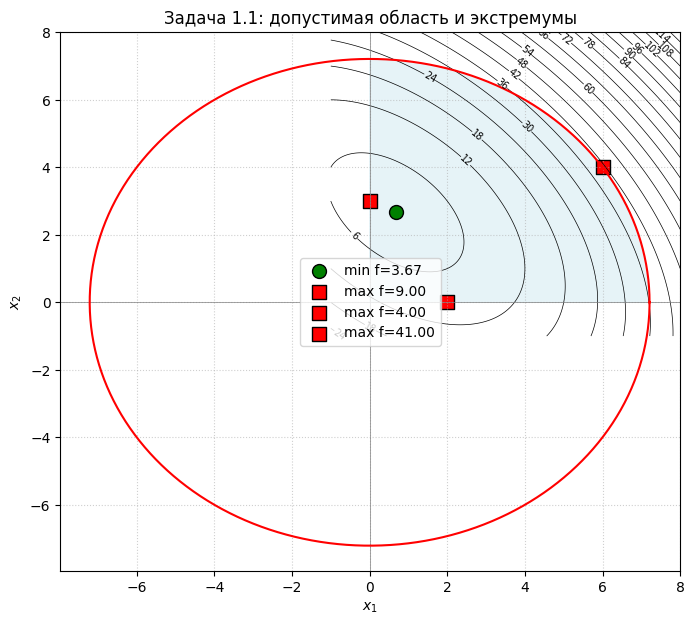


Строим график для задачи 1.2...


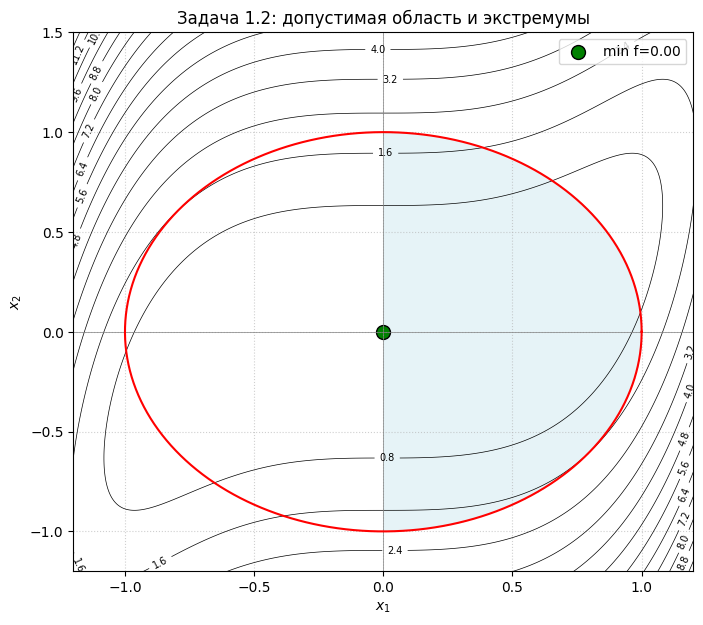


Строим график для задачи 1.3...


/tmp/ipykernel_796/1727090357.py:236: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(); plt.grid(True, linestyle=':', alpha=0.6)


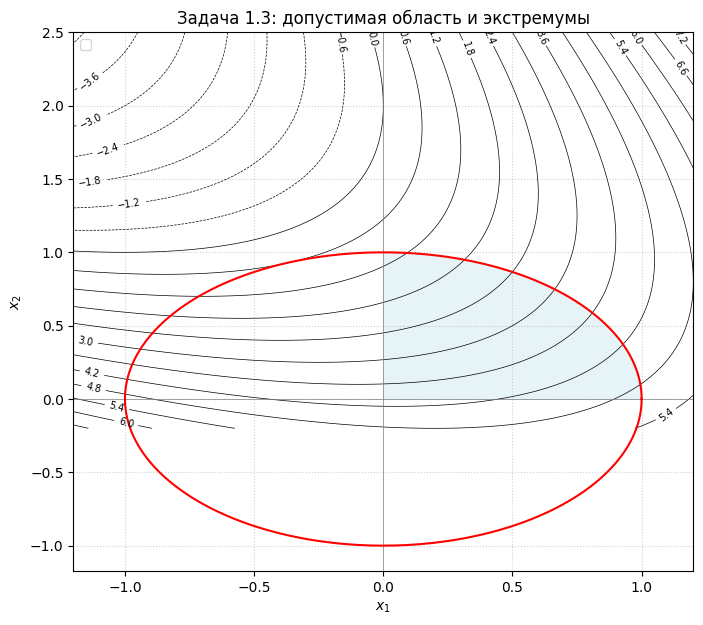


Строим график для задачи 1.4...


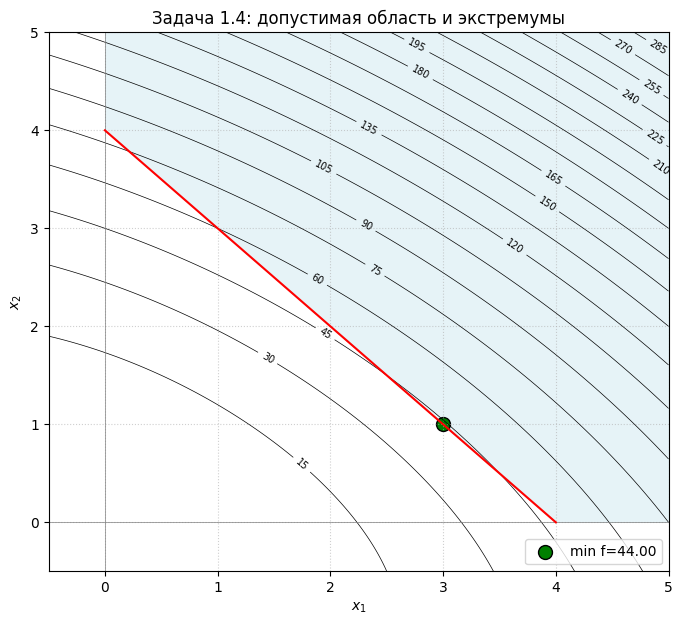


Строим график для задачи 1.5...


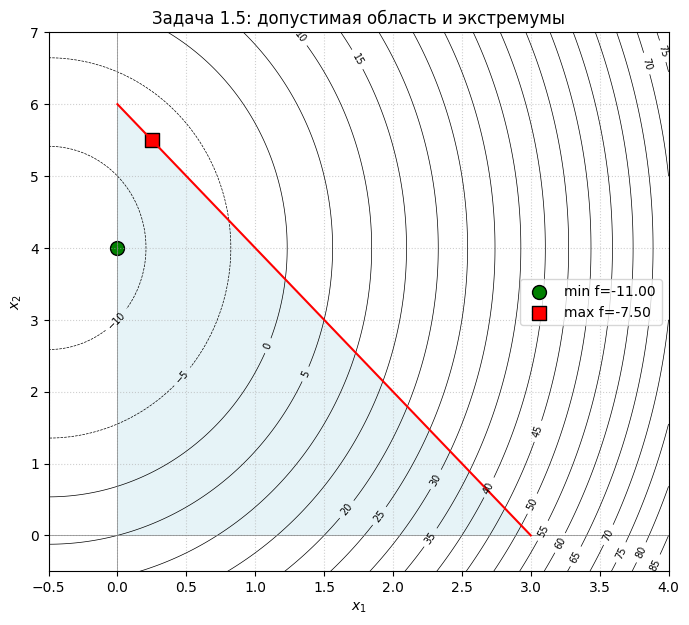

In [5]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

def solve_inequality_extr(f_expr, g_list, mode='extr'):
    x1, x2 = sp.symbols('x1 x2', real=True)
    lam_symbols = sp.symbols(f'lam0:{len(g_list)+1}')
    lam0 = lam_symbols[0]
    lam = lam_symbols[1:]

    L = lam0 * f_expr + sum(lj * gj for lj, gj in zip(lam, g_list))
    grad_L = [sp.diff(L, var) for var in (x1, x2)]

    candidates = []

    for lam0_val in [0, 1]:
        grad_eqs = [eq.subs(lam0, lam0_val) for eq in grad_L]
        for active_mask in product([0,1], repeat=len(g_list)):
            eqs = list(grad_eqs)
            for j, (gj, lam_j, active) in enumerate(zip(g_list, lam, active_mask)):
                if active:
                    eqs.append(gj)
                else:
                    eqs.append(lam_j)
            try:
                sols = sp.solve(eqs, [x1, x2] + list(lam), dict=True)
            except Exception:
                continue
            for sol in sols:
                # Проверка вещественности и конечности всех переменных
                try:
                    numeric_check = True
                    for v in sol.keys():
                        val = sp.N(sol[v])
                        if not (val.is_real and val.is_finite):
                            numeric_check = False
                            break
                    if not numeric_check:
                        continue
                except Exception:
                    continue

                # Допустимость: g_j(x) <= 0
                feasible = True
                for gj in g_list:
                    try:
                        val = float(sp.N(gj.subs(sol)))
                        if val > 1e-6:
                            feasible = False
                            break
                    except (TypeError, ValueError):
                        feasible = False
                        break
                if not feasible:
                    continue

                sol[lam0] = lam0_val
                candidates.append(sol)

    # Удаление дубликатов по (x1,x2)
    unique = {}
    for cand in candidates:
        key = (float(sp.N(cand[x1])), float(sp.N(cand[x2])))
        if key not in unique:
            unique[key] = cand
    cand_list = list(unique.values())

    results = []
    for cand in cand_list:
        lam0_val = cand[lam0]
        if lam0_val == 0:
            continue

        lj = [float(sp.N(cand[l])) for l in lam]
        all_nonneg = all(l >= -1e-6 for l in lj)
        all_nonpos = all(l <= 1e-6 for l in lj)
        if all_nonneg and mode in ('min', 'extr'):
            extr_type = 'min'
        elif all_nonpos and mode in ('max', 'extr'):
            extr_type = 'max'
        else:
            continue

        # Достаточные условия второго порядка
        L_classical = f_expr + sum(lj * gj for lj, gj in zip(lam, g_list))
        hess = sp.hessian(L_classical, (x1, x2))
        hess_num = np.array(hess.subs(cand)).astype(np.float64)

        active_indices = []
        for j, gj in enumerate(g_list):
            try:
                if abs(float(sp.N(gj.subs(cand)))) < 1e-6:
                    active_indices.append(j)
            except Exception:
                pass

        if not active_indices:
            eigvals = np.linalg.eigvalsh(hess_num)
            if extr_type == 'min' and np.all(eigvals > 0):
                second_order = 'подтверждён'
            elif extr_type == 'max' and np.all(eigvals < 0):
                second_order = 'подтверждён'
            else:
                second_order = 'не выполнен'
        else:
            # Матрица градиентов активных ограничений
            A_rows = []
            for j in active_indices:
                grad_gj = [sp.N(sp.diff(g_list[j], v).subs(cand)) for v in (x1, x2)]
                A_rows.append([float(grad_gj[0]), float(grad_gj[1])])
            A = np.array(A_rows)

            _, s, Vt = np.linalg.svd(A, full_matrices=True)
            rank = np.sum(s > 1e-9)
            null_basis = Vt[rank:]
            if null_basis.shape[0] == 0:
                second_order = 'недостаточно направлений'
            else:
                P = null_basis.T
                hess_proj = P.T @ hess_num @ P
                eigvals = np.linalg.eigvalsh(hess_proj)
                if extr_type == 'min' and np.all(eigvals > 1e-6):
                    second_order = 'подтверждён'
                elif extr_type == 'max' and np.all(eigvals < -1e-6):
                    second_order = 'подтверждён'
                else:
                    second_order = 'не выполнен'

        f_val = float(sp.N(f_expr.subs(cand)))
        results.append({
            'x1': float(sp.N(cand[x1])),
            'x2': float(sp.N(cand[x2])),
            'f': f_val,
            'type': extr_type,
            'lambda0': float(lam0_val),
            'lambda': [float(sp.N(cand[l])) for l in lam],
            'second_order': second_order
        })
    return results

x1, x2 = sp.symbols('x1 x2', real=True)

problems = [
    {'name': '1.1',
     'f': (x1 - 2)**2 + (x2 - 3)**2 + x1*x2,
     'g': [x1**2 + x2**2 - 52, -x1, -x2],
     'mode': 'extr'},
    {'name': '1.2',
     'f': (x1**3 - x2)**2 + x2**2,
     'g': [x1**2 + x2**2 - 1, -x1],
     'mode': 'extr'},
    {'name': '1.3',
     'f': x1**2 + 2*x1*x2 + (x2 - 2)**2,
     'g': [x1**2 + x2**2 - 1, -x1, -x2],
     'mode': 'min'},
    {'name': '1.4',
     'f': 3*x1**2 + 4*x1*x2 + 5*x2**2,
     'g': [4 - x1 - x2, -x1, -x2],
     'mode': 'min'},
    {'name': '1.5',
     'f': 4*x1**2 + 4*x1 + x2**2 - 8*x2 + 5,
     'g': [2*x1 + x2 - 6, -x1, -x2],
     'mode': 'extr'}
]

for prob in problems:
    print(f"\n========== Задача {prob['name']} ==========")
    res = solve_inequality_extr(prob['f'], prob['g'], mode=prob['mode'])
    if not res:
        print("Экстремумы не найдены (или не удовлетворяют условиям).")
    for i, r in enumerate(res):
        lam_str = ", ".join(f"{v:.4f}" for v in r['lambda'])
        print(f"  Точка {i+1}: x=({r['x1']:.6f}, {r['x2']:.6f}), "
              f"f={r['f']:.6f}, тип={r['type']}, "
              f"λ=({lam_str}), дост.усл.II: {r['second_order']}")


for prob in problems:
    print(f"\nСтроим график для задачи {prob['name']}...")
    res = solve_inequality_extr(prob['f'], prob['g'], mode=prob['mode'])

    # Границы осей подобраны под каждую задачу
    if prob['name'] == '1.1':
        x1_r = np.linspace(-1, 8, 400)
        x2_r = np.linspace(-1, 8, 400)
    elif prob['name'] == '1.2':
        x1_r = np.linspace(-1.2, 1.2, 400)
        x2_r = np.linspace(-1.2, 1.5, 400)
    elif prob['name'] == '1.3':
        x1_r = np.linspace(-1.2, 1.2, 400)
        x2_r = np.linspace(-0.2, 2.5, 400)
    elif prob['name'] == '1.4':
        x1_r = np.linspace(-0.5, 5, 400)
        x2_r = np.linspace(-0.5, 5, 400)
    else:
        x1_r = np.linspace(-0.5, 4, 400)
        x2_r = np.linspace(-0.5, 7, 400)

    X1, X2 = np.meshgrid(x1_r, x2_r)
    F_num = sp.lambdify((x1, x2), prob['f'], 'numpy')
    F_vals = F_num(X1, X2)

    mask = np.ones_like(X1, dtype=bool)
    for g in prob['g']:
        g_num = sp.lambdify((x1, x2), g, 'numpy')
        mask &= (g_num(X1, X2) <= 1e-6)

    plt.figure(figsize=(8, 7))
    plt.contourf(X1, X2, mask, levels=[0, 0.5, 1], alpha=0.3, colors=['white', 'lightblue'])
    contours = plt.contour(X1, X2, F_vals, levels=20, colors='black', linewidths=0.5)
    plt.clabel(contours, inline=True, fontsize=7)
    plt.axhline(0, color='gray', lw=0.5)
    plt.axvline(0, color='gray', lw=0.5)

    if prob['name'] in ('1.1', '1.2', '1.3'):
        theta = np.linspace(0, 2*np.pi, 400)
        if prob['name'] == '1.1':
            plt.plot(np.sqrt(52)*np.cos(theta), np.sqrt(52)*np.sin(theta), 'r-', lw=1.5)
        else:
            plt.plot(np.cos(theta), np.sin(theta), 'r-', lw=1.5)
    elif prob['name'] == '1.4':
        t = np.linspace(0, 4, 100)
        plt.plot(t, 4 - t, 'r-', lw=1.5)
    elif prob['name'] == '1.5':
        t = np.linspace(0, 3, 100)
        plt.plot(t, 6 - 2*t, 'r-', lw=1.5)

    for r in res:
        color = 'green' if r['type'] == 'min' else 'red'
        marker = 'o' if r['type'] == 'min' else 's'
        plt.scatter(r['x1'], r['x2'], c=color, marker=marker, s=100, edgecolors='k',
                    label=f"{r['type']} f={r['f']:.2f}")
    plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
    plt.title(f"Задача {prob['name']}: допустимая область и экстремумы")
    plt.legend(); plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()